In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D

In [2]:
a = 1
rh = 1 + math.sqrt(1 - a**2)
print("rh = ",rh)

rh =  1.0


**Ορισμός συναρτήσεων**

In [3]:
def gtt(r):
  return -(1 - (2/r))
def gtφ(r):
  return -2*a/r
def gφφ(r):
  return r**2 + a**2 + (2*(a**2))/r

def Δ(r):
  return r**2 - 2*r + a**2
def grr(r):
  return (r**2)/Δ(r)


**Αρχικές Συνθήκες**

In [4]:
r0 = 1.2
φ0 = 0

# Αρχική θέση του σωματιδίου
x0 = r0*np.cos(φ0)
y0 = r0*np.sin(φ0)

**Ορισμός της ποσότητας l μέσω της οποίας θα μπορούμε να ορίσουμε το δυναμικό V+**

In [5]:
l = -0.03

Ορισμός του δυναμικού V+(r)

In [6]:
def V1(r):
  return ((2*r*a + (r**2)*np.sqrt(Δ(r)))/((r**2+a**2)**2 - a**2*Δ(r)))*l


# Αν l > 0, για τις επιτρεπόμενες τροχιές φωτονίων ισχύει Ε > V+. Προκειμένου
# να επιλέγεται με ευκολία η ενέργεια του φωτονίου, ακριβώς από κάτω σχηματίζεται η
# συνάρτηση V+(r)



Ορισμός του δυναμικού V-(r)

In [7]:
def V2(r):
  return (2*r*a - r**2*np.sqrt(Δ(r)))*l/((r**2+a**2)**2 - a**2*Δ(r))

# Αν l < 0, για τις επιτρεπόμενες τροχιές φωτονίων ισχύει Ε > V+. Προκειμένου
# να επιλέγεται με ευκολία η ενέργεια του φωτονίου, ακριβώς από κάτω σχηματίζεται η
# συνάρτηση V+(r)

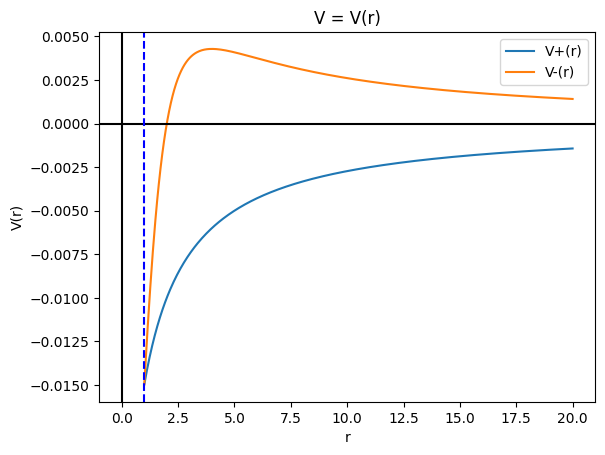

In [8]:
x_values = np.linspace(rh+0.01, 20, 500)
y_values = V1(x_values)

x_values2 = np.linspace(rh, 20, 500)
y_values2 = V2(x_values2)

plt.plot(x_values, y_values, label = 'V+(r)')
plt.plot(x_values2, y_values2, label = 'V-(r)')

plt.xlabel('r')
plt.ylabel('V(r)')
plt.title('V = V(r)')
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.axvline(rh,color = 'blue', linestyle = '--')
#plt.axhline(e, color = 'red')
#plt.axis("equal")
#plt.xlim(2,2.3)
plt.legend()


plt.show()

**Ενέργεια Φωτονίου**

In [78]:
e = -0.0005

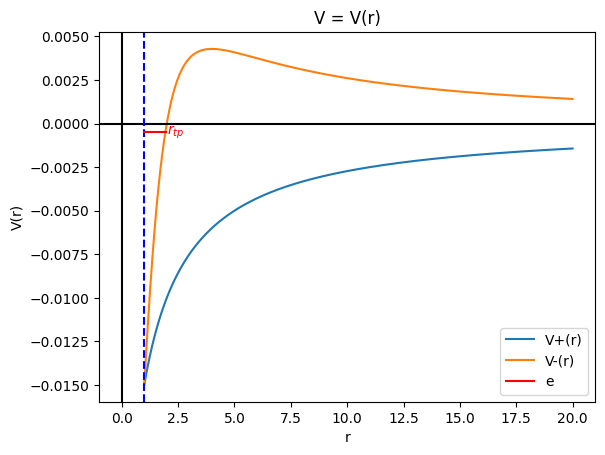

In [79]:
x_values = np.linspace(rh+0.01, 20, 500)
y_values = V1(x_values)

x_values2 = np.linspace(rh, 20, 500)
y_values2 = V2(x_values2)

plt.plot(x_values, y_values, label = 'V+(r)')
plt.plot(x_values2, y_values2, label = 'V-(r)')

plt.xlabel('r')
plt.ylabel('V(r)')
plt.title('V = V(r)')
plt.axhline(0, color='black')
plt.axvline(0, color='black')
#plt.axhline(e, color = 'red')
#plt.axis("equal")
#plt.xlim(2,2.3)
plt.axvline(rh,color = 'blue', linestyle = '--')
plt.plot([rh, 1.98], [e, e], color='red', linestyle='-', label = 'e')
# plt.plot([r0, 2], [0, 0], color='red', linestyle='-')
# plt.plot([r0, 1.9], [-0.001, -0.001], color='red', linestyle='-', label = 'e')
# plt.plot([2.7, 2.7], [0,e], color='red', linestyle='--')
plt.text(2, 0, r'$r_{tp}$', color='red', ha='left', va='top')
plt.legend()
plt.show()

In [80]:
# Συντεταγμένη r στην οποία έχουμε την αλλάγη προσήμου της γωνιακής ταχύτητας του σωματιδίου
rtpφ = 2*(1-(a*e/l))
print("rtpφ = ", rtpφ)

rtpφ =  1.9666666666666666


Αν k = -1, το φωτόνιο αρχικά οδεύει προς την μαύρη τρύπα, ενώ
αν k = +1, το φωτόνιο αρχικά οδεύει μακριά από τη μαύρη τρύπα.

In [81]:
k = +1

In [82]:
def f1(r):
  return k*math.sqrt((((r**2+a**2)**2 - a**2*Δ(r))/r**4)*(e - V1(r))*(e - V2(r)))

In [83]:


def f2(r):
  return -(gtt(r)*l + gtφ(r)*e)/(Δ(r))

Υπολογισμός των ποσοτήτων uφ0 και ut0

In [84]:
# Υπολογισμός των ut0, uφ0 και ur0
ut0 = (gφφ(r0)*e + gtφ(r0)*l)/Δ(r0)
uφ0 = -(gtt(r0)*l + gtφ(r0)*e)/Δ(r0)

print("ut0 = ",ut0)
print("uφ0 = ",uφ0)

ut0 =  1.1986666666666657
uφ0 =  0.4791666666666663


In [85]:
# Eπιβεβαιώση της σχέσης u u = 0 και υπολογισμός της αρχικής ακτινικής ταχύτητας
#Έχοντας επιλέξει σωστά την ενέργεια του φωτονίου αναλογιζόμενοι το διάγραμμα, δεν περιμένουμε
#να μας εμφανίσει error. Αν όμως εμφανιστεί, αρκεί να αλλάξουμε την ενέργεια.

u2  = -(gtt(r0)*(ut0**2) + gφφ(r0)*(uφ0**2) + 2*gtφ(r0)*ut0*uφ0)/(grr(r0))
if u2 > 0:
  ur0 = math.sqrt(u2)
  print("ur0 = ",ur0)
else:
  print(u2)
  print("ERROR")


ur0 =  0.019561631000696408


In [86]:
b1 = 0   #Aρχική χρονική στιγμή του σωματιδίου
b2 = 300 #Τελική χρονική στιγμή του σωματιδίου

dλ = 0.001 #Χρονικό βήμα

N = int((b2-b1)/dλ) #Αριθμός βημάτων

# Λίστες

r = [0]*(N+1)
φ = [0]*(N+1)
λ = [0]*(N+1)

# Αρχικές συνθήκες

r[0] = r0
φ[0] = φ0
λ[0] = b1

rstop = rh + 0.05 # Η απόσταση από το κέντρο της μαύρης τρύπας που θα σταματήσει η επανάληψη της RK4. Στην προκειμένη περίπτωση η απόσταση αυτή θέλω να είναι ο ορίζοντας της KBH

**Runge Kutta για τη λύση της f1(r)**

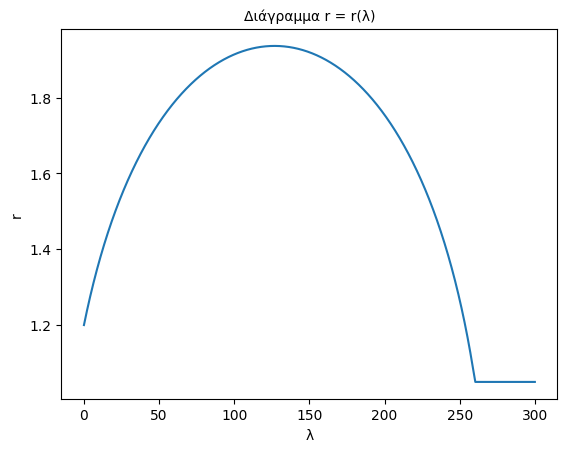

In [87]:
k1 = 0
k2 = 0
k3 = 0
k4 = 0

c = 1
if l > 0:

  for i in range(N):
    if (e - V1(r[i]+k3)) > 0:
      if r[i] > rstop:

        k1 = c*dλ*f1(r[i])
        k2 = c*dλ*f1(r[i] + 0.5*k1)
        k3 = c*dλ*f1(r[i] + 0.5*k2)
        k4 = c*dλ*f1(r[i] + k3)

        r[i+1] = r[i] + (k1 + 2*k2 + 2*k3 + k4)/6
        λ[i+1] = λ[i] + dλ
      else:
        r[i+1] = r[i]
        λ[i+1] = λ[i] + dλ

    else:
      c = -c

      k1 = c*dλ*f1(r[i])
      k2 = c*dλ*f1(r[i] + 0.5*k1)
      k3 = c*dλ*f1(r[i] + 0.5*k2)
      k4 = c*dλ*f1(r[i] + k3)


      r[i+1] = r[i] + (k1 + 2*k2 + 2*k3 + k4)/6
      λ[i+1] = λ[i] + dλ

  plt.plot(λ, r)
  plt.xlabel('λ')
  plt.ylabel('r')
  plt.title('Διάγραμμα r = r(λ)', fontsize = 10)


else:
  for i in range(N):
    if (e - V2(r[i]+k3)) > 0:
      if r[i] > rstop:

        k1 = c*dλ*f1(r[i])
        k2 = c*dλ*f1(r[i] + 0.5*k1)
        k3 = c*dλ*f1(r[i] + 0.5*k2)
        k4 = c*dλ*f1(r[i] + k3)

        r[i+1] = r[i] + (k1 + 2*k2 + 2*k3 + k4)/6
        λ[i+1] = λ[i] + dλ
      else:
        r[i+1] = r[i]
        λ[i+1] = λ[i] + dλ

    else:
      c = -c

      k1 = c*dλ*f1(r[i])
      k2 = c*dλ*f1(r[i] + 0.5*k1)
      k3 = c*dλ*f1(r[i] + 0.5*k2)
      k4 = c*dλ*f1(r[i] + k3)


      r[i+1] = r[i] + (k1 + 2*k2 + 2*k3 + k4)/6
      λ[i+1] = λ[i] + dλ

  plt.plot(λ, r)
  plt.xlabel('λ')
  plt.ylabel('r')
  plt.title('Διάγραμμα r = r(λ)', fontsize = 10)


**Runge Kutta για λύση της f2(r)**

In [88]:
k1 = 0
k2 = 0
k3 = 0
k4 = 0

for i in range(N):
  if r[i] > rstop:
    k1 = dλ*f2(r[i])
    k2 = dλ*f2((r[i] + r[i+1])/2)
    k3 = k2
    k4 = dλ*f2(r[i+1])

    φ[i+1] = φ[i] + (k1 + 2*k2 + 2*k3 + k4)/6

  else:
    φ[i+1] = φ[i]

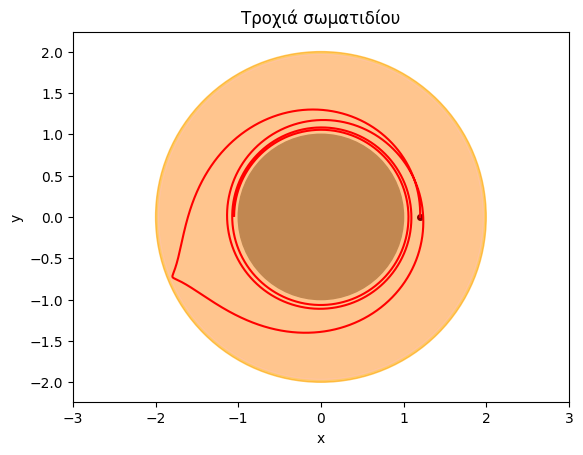

In [89]:
x = [0]*(N)
y = [0]*(N)

# Συντεταγμένη rtpφ που αλλάζει πρόσημο η γωνιακή ταχύτητα
rtpφ = 2*(1-(a*e/l))

for i in range(N):
  x[i] = r[i]*math.cos(φ[i])
  y[i] = r[i]*math.sin(φ[i])

circle1 = plt.Circle((0, 0), rh, color='black', alpha = 1)
circle2 = plt.Circle((0, 0), 2, color='orange', alpha = 0.6)
circle3 = plt.Circle((0, 0), rtpφ, color='pink', alpha = 0.4)
plt.plot(x0, y0, 'o', color='darkred', markersize = '4')
plt.gca().add_artist(circle1)
plt.gca().add_artist(circle2)
plt.gca().add_artist(circle3)

plt.plot(x,y,color = 'red')
plt.title("Τροχιά σωματιδίου")
plt.axis("equal")
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-3,3)
plt.ylim(-3,3)
# plt.legend()
plt.show()

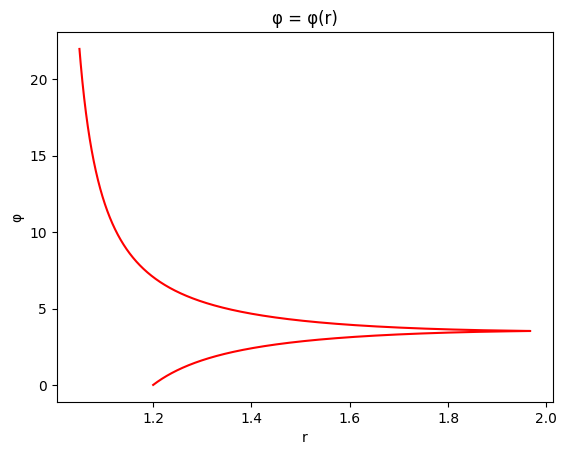

In [ ]:
plt.plot(r,φ,color = 'red')
plt.title("φ = φ(r)")
plt.xlabel('r')
plt.ylabel('φ')
# plt.ylim(-3.4,0.5)
# plt.plot([rtpφ, rtpφ], [-3.4,-2.8 ], color='orange', linestyle='--')
# plt.text(rtpφ+0.3, -3.2, r'$r_{tp_{\phi}}$', color='orange', ha='left', va='top')
plt.show()

In [ ]:
3#Τροχιά στην οποία βλέπουμε το φωτόνιο μηδενικής ενέργειας να χτυπάει στο Static limit και στην
#συνέχεια να πέφτει μέσα στη τρύπα
#a = 1
#r0 = 1.2
#φ0 = 0.9*np.pi
#l = -0.02
#e = 0.


In [ ]:
c1 = V1(rtpφ) - e
c2 = V2(rtpφ) - e
print("c1 = ",c1)
print("c2 = ",c2)

c1 =  -0.00658896321070234
c2 =  4.9623435177955584e-05


In [ ]:
rtpφ

2.1